# Ergebnisse – Experiment-Summary
- Pro Experiment & Datensatz eine Tabelle (Mittelwert und Standardabweichung **über die Seeds** in getrennten Spalten)
- Tabellen ausschließlich als LaTeX (booktabs), Abbildungen ausschließlich als PDF; Captions und Achsen auf Englisch fürs Paper
- Quelle: alle MLflow-Runs aus `./mlruns`; fehlende/leere Experimente werden übersprungen

In [1]:
import os
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "result_tables"
DIAGRAM_DIR = "diagrams"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(DIAGRAM_DIR, exist_ok=True)
DS_ABBR = {"fake_jobs": "fj", "airbnb_paris": "airbnb"}
DS_LABEL = {"fake_jobs": "Fake Job Postings", "airbnb_paris": "Airbnb Paris"}
datasets = ["fake_jobs", "airbnb_paris"]

# explicit mapping: experiment name -> (dataset, section); der Name wird nicht geparst
EXPERIMENTS = {
    "fake_jobs_experiment_1": ("fake_jobs", "exp1"),
    "fake_jobs_experiment_2": ("fake_jobs", "exp2"),
    "fake_jobs_preliminary_experiment": ("fake_jobs", "preliminary"),
    "fake_jobs_experiment_3": ("fake_jobs", "exp3"),
    "airbnb_paris_experiment_1": ("airbnb_paris", "exp1"),
    "airbnb_paris_experiment_2": ("airbnb_paris", "exp2"),
    "airbnb_paris_preliminary_experiment": ("airbnb_paris", "preliminary"),
    "airbnb_paris_experiment_3": ("airbnb_paris", "exp3"),
}

## Runs laden

In [2]:
mlflow.set_tracking_uri("file:./mlruns")

parts = []
for name in EXPERIMENTS:
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        continue
    runs = mlflow.search_runs([exp.experiment_id])
    if len(runs) == 0:
        continue
    runs["experiment"] = name
    parts.append(runs)

df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(f"{len(df)} Runs aus {len(parts)} Experimenten geladen")

/home/debian/TFM_master_thesis/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


240 Runs aus 8 Experimenten geladen


## Aufbereiten
- Datensatz und Abschnitt aus der expliziten Zuordnung; Metrik-Spalten vereinheitlichen

In [3]:
if len(df):
    df["dataset"] = df["experiment"].map(lambda e: EXPERIMENTS[e][0])
    df["section"] = df["experiment"].map(lambda e: EXPERIMENTS[e][1])
    df["model"] = df["tags.mlflow.runName"] if "tags.mlflow.runName" in df.columns else df["run_id"]
    df = df.rename(columns={"metrics.auprc": "AUPRC", "metrics.auc_roc": "AUROC", "metrics.runtime_s": "runtime_s"})
    for col in ["AUPRC", "AUROC", "runtime_s"]:
        if col not in df.columns:
            df[col] = np.nan
    seeds = sorted(df["params.seed"].dropna().unique()) if "params.seed" in df.columns else []
    print("Datensätze:", df["dataset"].unique().tolist(), "| Abschnitte:", df["section"].unique().tolist())
    print("Seeds:", seeds)

Datensätze: ['fake_jobs', 'airbnb_paris'] | Abschnitte: ['exp1', 'exp2', 'preliminary', 'exp3']
Seeds: ['1', '2', '3']


## Experiment 1 – Unsupervised Outlier Detection
- TFMs (TabPFN unsup., AnoLLM, FoMo-0D) vs. PyOD-Baselines
- AUPRC und AUROC je mit eigener SD-Spalte; Laufzeit als Mittelwert
- **Eine Standardabweichung von exakt 0 wäre ein Warnsignal** (Seed nicht durchgereicht)

=== Experiment 1 – fake_jobs ===


,AUPRC,SD (AUPRC),AUROC,SD (AUROC),Runtime (s)
Model,,,,,
anollm,0.0916,0.0085,0.6261,0.0110,5400.6
iforest,0.0844,0.0103,0.6188,0.0145,2.3
ecod,0.0761,0.0039,0.6264,0.0090,0.6
autoencoder,0.0737,0.0018,0.6152,0.0108,143.3
fomo_od,0.0673,0.0061,0.6351,0.0194,0.2
tabpfn_unsup,0.0625,0.0028,0.5242,0.0343,275.4
loda,0.0548,0.0157,0.5040,0.0693,0.5


=== Experiment 1 – airbnb_paris ===


,AUPRC,SD (AUPRC),AUROC,SD (AUROC),Runtime (s)
Model,,,,,
ecod,0.1002,0.0108,0.7413,0.0137,0.8
iforest,0.0941,0.0193,0.7214,0.0129,2.4
loda,0.0836,0.0207,0.6545,0.0214,0.6
tabpfn_unsup,0.0753,0.0031,0.6843,0.0074,954.1
anollm,0.0719,0.0094,0.6593,0.0121,5923.7
autoencoder,0.0684,0.0089,0.6452,0.0170,155.0
fomo_od,0.0467,0.0009,0.5873,0.0051,0.2


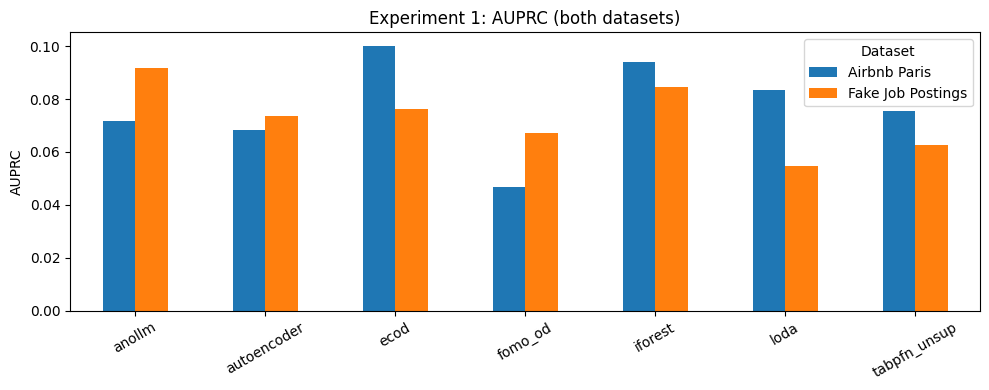

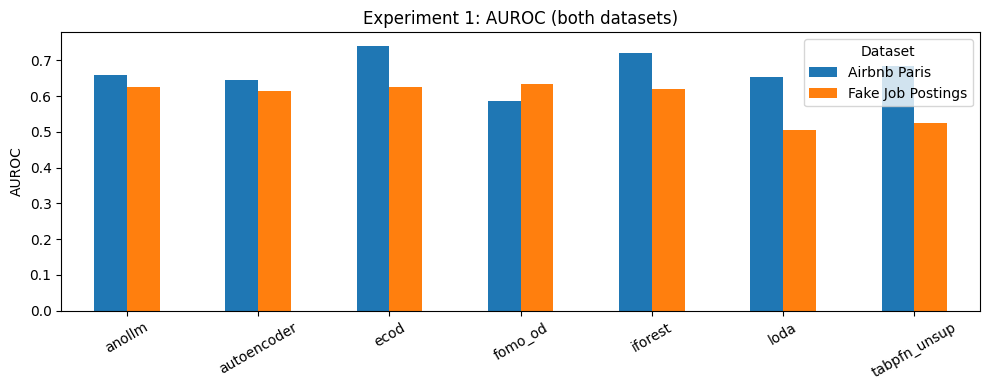

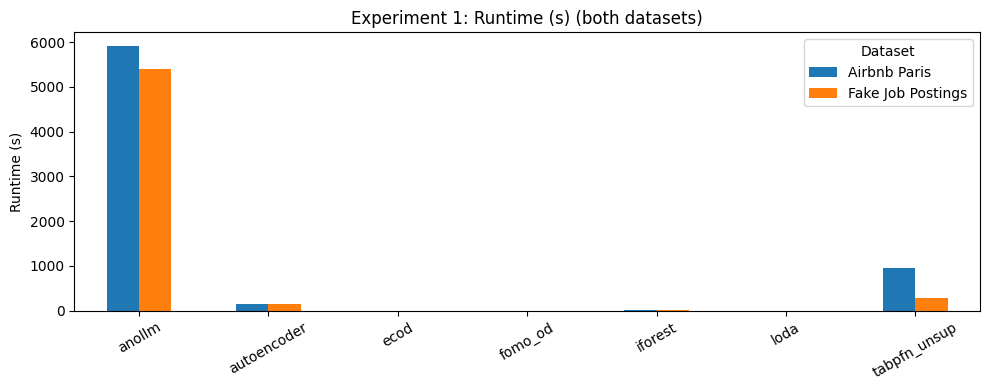

In [4]:
sub = df[df["section"] == "exp1"] if len(df) else df
if not len(sub):
    print("keine Exp-1-Runs")
else:
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        mean, std = g[["AUPRC", "AUROC", "runtime_s"]].mean(), g[["AUPRC", "AUROC"]].std()
        order = mean["AUPRC"].sort_values(ascending=False).index
        tab = pd.DataFrame({
            "AUPRC": mean["AUPRC"].map("{:.4f}".format),
            "SD (AUPRC)": std["AUPRC"].map("{:.4f}".format),
            "AUROC": mean["AUROC"].map("{:.4f}".format),
            "SD (AUROC)": std["AUROC"].map("{:.4f}".format),
            "Runtime (s)": mean["runtime_s"].map("{:.1f}".format),
        }).loc[order]
        tab.index.name = "Model"

        sty = (tab.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/exp1_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     column_format="lrrrrr",
                     caption=f"Experiment 1 -- unsupervised outlier detection on {DS_LABEL[ds]}: AUPRC, AUROC and runtime per model, averaged over three seeds.",
                     label=f"tab:exp1_{ds}")
        print(f"=== Experiment 1 – {ds} ===")
        display(tab)

    for metric, label, fname in [("AUPRC", "AUPRC", "auprc"), ("AUROC", "AUROC", "auroc"), ("runtime_s", "Runtime (s)", "runtime")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        piv.columns = [DS_LABEL[c] for c in piv.columns]
        ax = piv.plot.bar(figsize=(10, 4), rot=30)
        ax.set_title(f"Experiment 1: {label} (both datasets)")
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.legend(title="Dataset")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp1_{fname}.pdf", facecolor="white", edgecolor="white")
        plt.show()
        plt.close()

## Experiment 2 – Enhanced Baseline-Modelle
- Baselines auf semantisch vs. fastText vs. enhanced vs. enhanced+semantisch (`cleaned` steckt in Experiment 1)
- Je Repräsentation eine Metrik- und eine SD-Spalte; `n_runs` entfällt, es sind durchgängig 3 Seeds
- Hinweis: die `enhanced`-Varianten sind semi-supervised (Label-Leakage), nicht direkt mit den unsupervised Repräsentationen vergleichbar

=== Experiment 2 – fake_jobs: AUPRC ===


semantic_pca30         semantic_pca100         fast_text_pca30  \
                     AUPRC      SD           AUPRC      SD           AUPRC   
Detector                                                                     
autoencoder         0.0668  0.0083          0.0483  0.0032          0.0775   
ecod                0.0540  0.0009          0.0432  0.0003          0.0849   
iforest             0.0890  0.0051          0.0524  0.0056          0.1148   
loda                0.0515  0.0051          0.0450  0.0050          0.0652   

                    fast_text_pca100         enhanced         enhanced_pca30  \
                 SD            AUPRC      SD    AUPRC      SD          AUPRC   
Detector                                                                       
autoencoder  0.0070           0.0734  0.0091   0.1196  0.0113         0.0829   
ecod         0.0068           0.0678  0.0087   0.1199  0.0136         0.1104   
iforest      0.0128           0.0807  0.0149   0.1192  0.0192         0.1321   
loda         0.0111           0.0675  0.0116   0.1029  0.0164         0.1132   

                    enhanced_semantic_pca30          
                 SD                   AUPRC      SD  
Detector                                             
autoencoder  0.0057                  0.0817  0.0094  
ecod         0.0419                  0.0735  0.0075  
iforest      0.0091                  0.1176  0.0181  
loda         0.0328                  0.0748  0.0234

=== Experiment 2 – fake_jobs: AUROC ===


semantic_pca30         semantic_pca100         fast_text_pca30  \
                     AUROC      SD           AUROC      SD           AUROC   
Detector                                                                     
autoencoder         0.6020  0.0181          0.5167  0.0218          0.6272   
ecod                0.5439  0.0078          0.4749  0.0037          0.6079   
iforest             0.6429  0.0023          0.5251  0.0326          0.6817   
loda                0.5508  0.0402          0.4771  0.0317          0.5927   

                    fast_text_pca100         enhanced         enhanced_pca30  \
                 SD            AUROC      SD    AUROC      SD          AUROC   
Detector                                                                       
autoencoder  0.0195           0.6196  0.0267   0.7202  0.0283         0.6172   
ecod         0.0233           0.6105  0.0333   0.7613  0.0235         0.6797   
iforest      0.0156           0.6464  0.0356   0.7596  0.0253         0.7627   
loda         0.0463           0.6145  0.0370   0.7219  0.0473         0.7357   

                    enhanced_semantic_pca30          
                 SD                   AUROC      SD  
Detector                                             
autoencoder  0.0444                  0.6674  0.0197  
ecod         0.0461                  0.6389  0.0347  
iforest      0.0071                  0.7191  0.0277  
loda         0.0461                  0.6254  0.0760

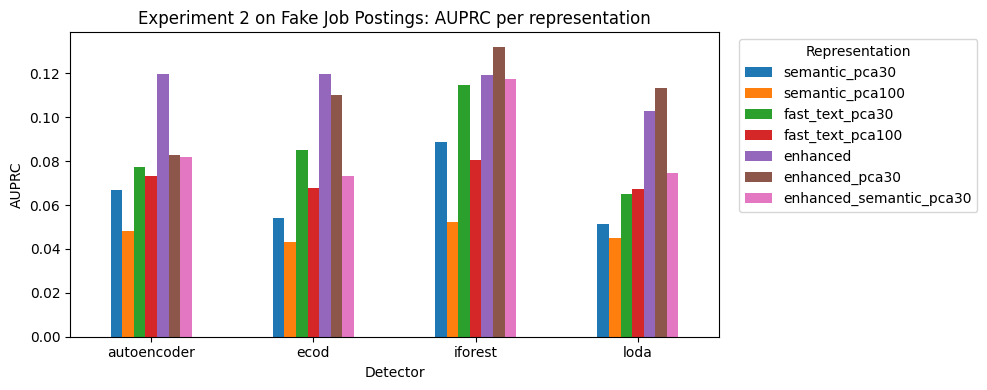

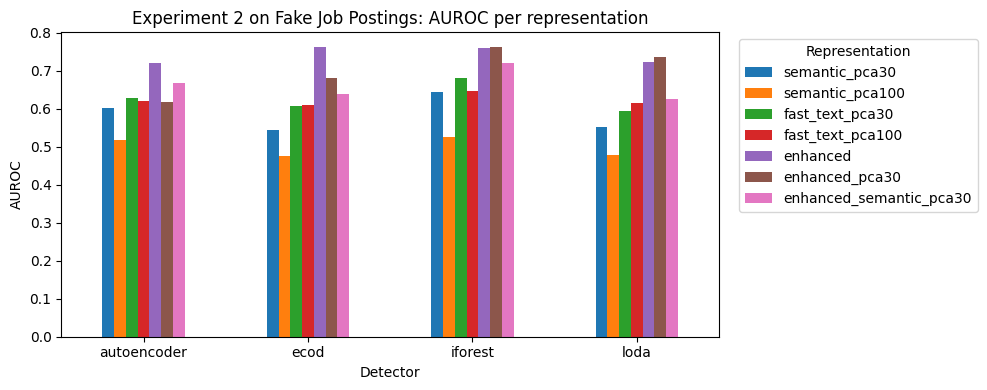

=== Experiment 2 – airbnb_paris: AUPRC ===


semantic_pca30         semantic_pca100         fast_text_pca30  \
                     AUPRC      SD           AUPRC      SD           AUPRC   
Detector                                                                     
autoencoder         0.0547  0.0014          0.0525  0.0047          0.0587   
ecod                0.0778  0.0056          0.0582  0.0030          0.0751   
iforest             0.0803  0.0103          0.0760  0.0087          0.0813   
loda                0.0555  0.0083          0.0510  0.0029          0.0812   

                    fast_text_pca100         enhanced         enhanced_pca30  \
                 SD            AUPRC      SD    AUPRC      SD          AUPRC   
Detector                                                                       
autoencoder  0.0123           0.0451  0.0010   0.0753  0.0066         0.0708   
ecod         0.0015           0.0511  0.0019   0.0388  0.0038         0.0762   
iforest      0.0124           0.0633  0.0035   0.0493  0.0038         0.0737   
loda         0.0121           0.0767  0.0148   0.0400  0.0018         0.0647   

                    enhanced_semantic_pca30          
                 SD                   AUPRC      SD  
Detector                                             
autoencoder  0.0064                  0.0760  0.0143  
ecod         0.0069                  0.0854  0.0052  
iforest      0.0119                  0.0876  0.0065  
loda         0.0166                  0.0508  0.0025

=== Experiment 2 – airbnb_paris: AUROC ===


semantic_pca30         semantic_pca100         fast_text_pca30  \
                     AUROC      SD           AUROC      SD           AUROC   
Detector                                                                     
autoencoder         0.5672  0.0092          0.5463  0.0073          0.5687   
ecod                0.6904  0.0040          0.6063  0.0020          0.6892   
iforest             0.6920  0.0074          0.6693  0.0062          0.6898   
loda                0.5739  0.0320          0.5592  0.0082          0.6566   

                    fast_text_pca100         enhanced         enhanced_pca30  \
                 SD            AUROC      SD    AUROC      SD          AUROC   
Detector                                                                       
autoencoder  0.0127           0.5581  0.0015   0.7107  0.0196         0.6859   
ecod         0.0042           0.6136  0.0057   0.5232  0.0277         0.7159   
iforest      0.0171           0.6621  0.0104   0.5668  0.0090         0.7042   
loda         0.0499           0.6460  0.0235   0.5399  0.0076         0.6341   

                    enhanced_semantic_pca30          
                 SD                   AUROC      SD  
Detector                                             
autoencoder  0.0205                  0.6501  0.0168  
ecod         0.0139                  0.7327  0.0061  
iforest      0.0068                  0.7248  0.0066  
loda         0.0783                  0.5582  0.0150

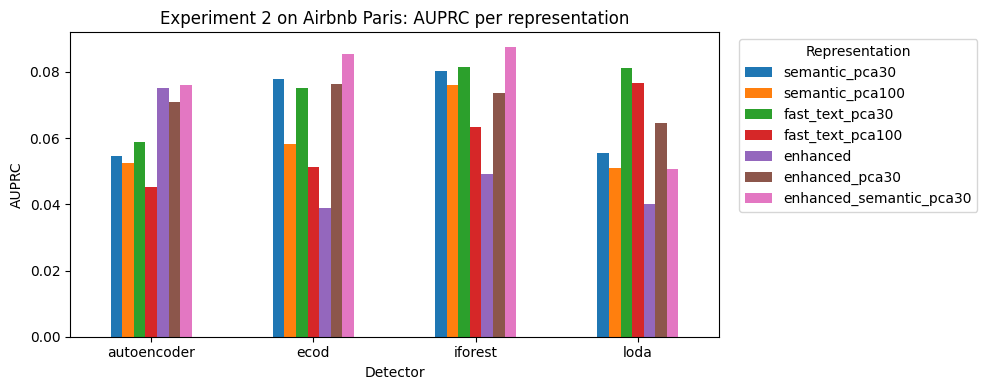

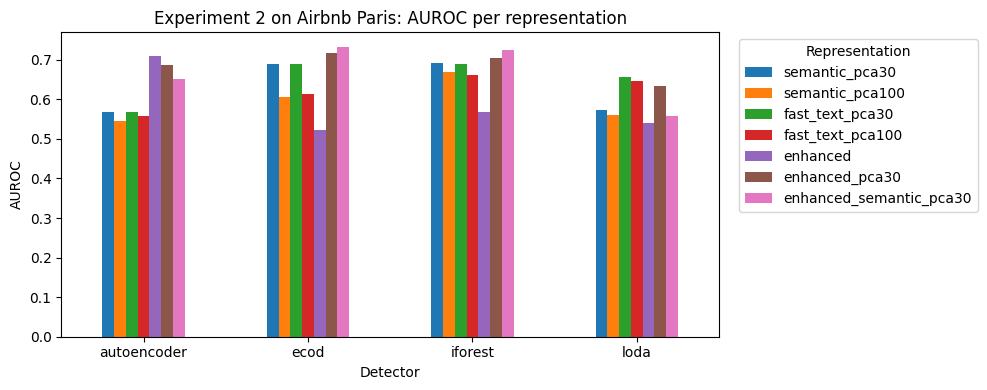

In [5]:
REP_ORDER = ["semantic_pca30", "semantic_pca100", "fast_text_pca30", "fast_text_pca100",
             "enhanced", "enhanced_pca30", "enhanced_semantic_pca30"]
FILE_STEM = {"AUPRC": "exp2", "AUROC": "exp2_auroc"}

for ds in datasets:
    sub = df[(df["section"] == "exp2") & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-2-Runs")
        continue
    reps = sub["params.representation"].unique().tolist()
    order = [r for r in REP_ORDER if r in reps] + [r for r in reps if r not in REP_ORDER]

    for metric in ["AUPRC", "AUROC"]:
        m = sub.pivot_table(index="params.detector", columns="params.representation", values=metric, aggfunc="mean").reindex(columns=order)
        sd = sub.pivot_table(index="params.detector", columns="params.representation", values=metric, aggfunc="std").reindex(index=m.index, columns=order)
        cols = {}
        for r in order:
            cols[(r, metric)] = m[r].map("{:.4f}".format)
            cols[(r, "SD")] = sd[r].map("{:.4f}".format)
        tab = pd.DataFrame(cols).where(m[order[0]].notna(), "--")
        tab.columns = pd.MultiIndex.from_tuples(tab.columns)
        tab.index.name = "Detector"

        sty = (tab.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/{FILE_STEM[metric]}_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     column_format="l" + "rr" * len(order),
                     caption=f"Experiment 2 -- enhanced baselines on {DS_LABEL[ds]}: {metric} per detector and representation, averaged over three seeds.",
                     label=f"tab:{FILE_STEM[metric]}_{ds}")
        print(f"=== Experiment 2 – {ds}: {metric} ===")
        display(tab)

    for metric, fname in [("AUPRC", "auprc"), ("AUROC", "auroc")]:
        piv = sub.pivot_table(index="params.detector", columns="params.representation", values=metric, aggfunc="mean").reindex(columns=order)
        ax = piv.plot.bar(figsize=(10, 4), rot=0)
        ax.set_title(f"Experiment 2 on {DS_LABEL[ds]}: {metric} per representation")
        ax.set_ylabel(metric)
        ax.set_xlabel("Detector")
        ax.legend(title="Representation", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp2_{fname}_{DS_ABBR[ds]}.pdf", facecolor="white", edgecolor="white")
        plt.show()
        plt.close()

## Vorexperiment – Semantische Relevanz (SHAP)
- ConTextTab-SHAP je Feature, Mittelwert und Standardabweichung über die Seeds
- Gruppenvergleich numerisch vs. Freitext als Summe der mittleren |SHAP|-Werte

=== Vorexperiment – fake_jobs: Top 20 Features ===


,mean abs. SHAP,SD,Type
Feature,,,
company_profile,0.1656,0.0296,text
has_company_logo,0.0411,0.0207,numeric
description,0.0384,0.0166,text
title,0.0341,0.0157,text
requirements,0.0293,0.0099,text
salary_avg,0.0192,0.0161,numeric
benefits,0.0172,0.0103,text
industry,0.0101,0.0064,numeric
has_questions,0.0095,0.0027,numeric


--- numerisch vs. Freitext (Summe, Mittelwert über die Seeds) ---
  numeric_total   0.12638 ± 0.05254
  text_total      0.28463 ± 0.06121


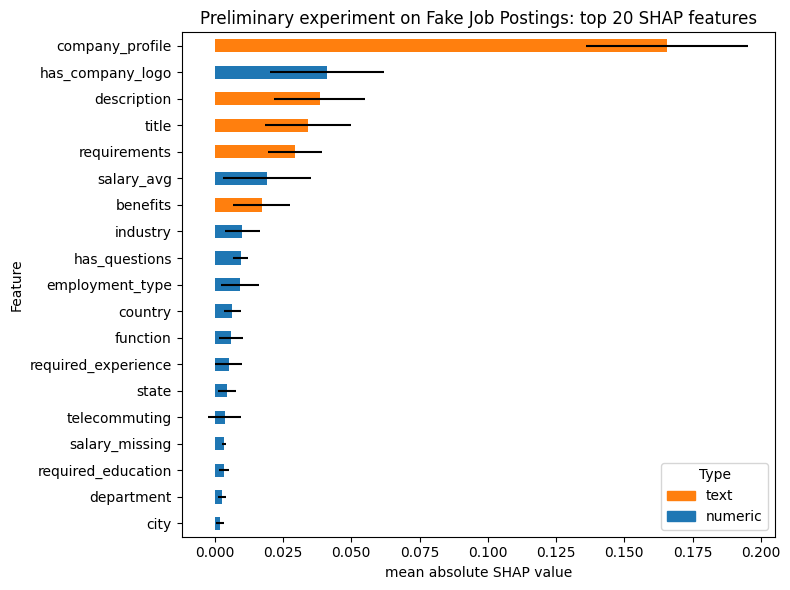

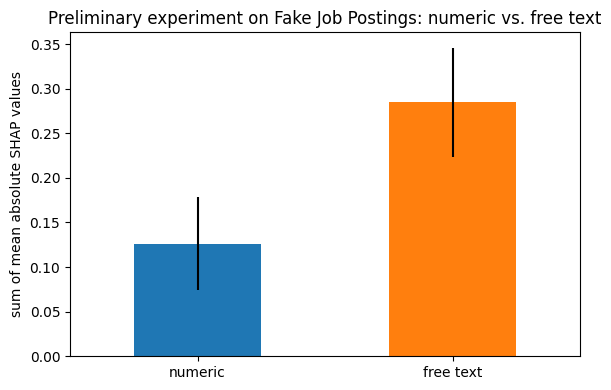

=== Vorexperiment – airbnb_paris: Top 20 Features ===


,mean abs. SHAP,SD,Type
Feature,,,
calculated_host_listings_count_entire_homes,0.0281,0.0370,numeric
calculated_host_listings_count,0.0281,0.0302,numeric
name,0.0259,0.0131,text
description,0.0245,0.0284,text
amenities_count,0.0193,0.0165,numeric
estimated_occupancy_l365d,0.0170,0.0121,numeric
host_tenure_days,0.0143,0.0050,numeric
instant_bookable,0.0123,0.0075,numeric
availability_365,0.0119,0.0051,numeric


--- numerisch vs. Freitext (Summe, Mittelwert über die Seeds) ---
  numeric_total   0.26747 ± 0.09785
  text_total      0.05482 ± 0.04210


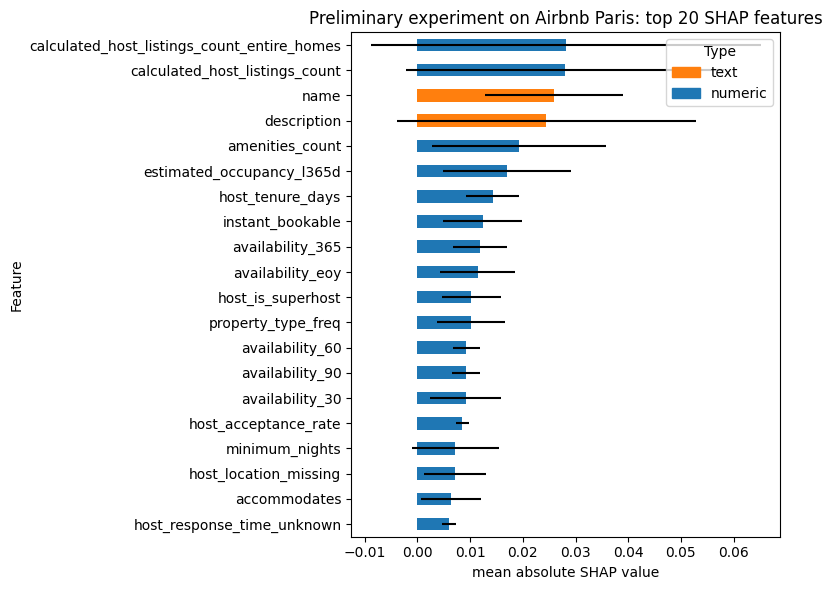

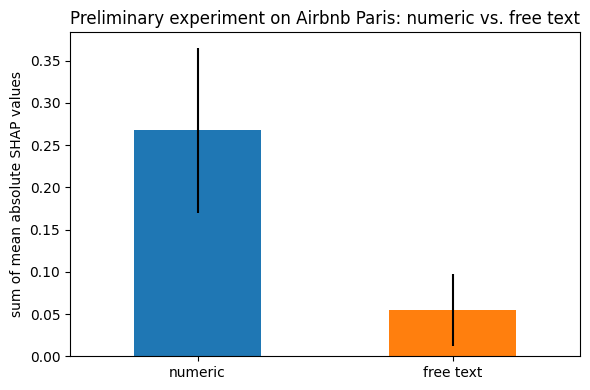

In [6]:
for ds in datasets:
    sub = df[(df["section"] == "preliminary") & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        continue
    agg_cols = ["metrics.numeric_total", "metrics.text_total", "metrics.numeric_mean", "metrics.text_mean"]
    rel_cols = [c for c in sub.columns if c.startswith("metrics.") and c not in agg_cols and sub[c].notna().any()]

    mean, std = sub[rel_cols].mean(), sub[rel_cols].std()
    mean.index = [c.replace("metrics.", "") for c in mean.index]
    std.index = [c.replace("metrics.", "") for c in std.index]

    top = pd.DataFrame({"mean abs. SHAP": mean, "SD": std})
    top["Type"] = ["text" if i.startswith("text_") else "numeric" for i in top.index]
    top = top.sort_values("mean abs. SHAP", ascending=False).head(20)
    top.index = [i.replace("text_", "").replace("num_", "") for i in top.index]
    top.index.name = "Feature"
    disp = top.copy()
    disp["mean abs. SHAP"] = disp["mean abs. SHAP"].map("{:.4f}".format)
    disp["SD"] = disp["SD"].map("{:.4f}".format)

    sty = (disp.style.format(escape=None)
           .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
           .map_index(lambda v: "font-weight: bold;", axis="columns")
           .hide(axis="index", names=True).hide(axis="columns", names=True))
    sty.to_latex(f"{RESULT_DIR}/preliminary_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                 column_format="lrrl",
                 caption=f"Preliminary experiment -- semantic relevance on {DS_LABEL[ds]}: top-20 SHAP features, averaged over three seeds.",
                 label=f"tab:preliminary_{ds}")
    print(f"=== Vorexperiment – {ds}: Top 20 Features ===")
    display(disp)

    print("--- numerisch vs. Freitext (Summe, Mittelwert über die Seeds) ---")
    for c in ["metrics.numeric_total", "metrics.text_total"]:
        if c in sub.columns and sub[c].notna().any():
            print(f"  {c.replace('metrics.', ''):15s} {sub[c].mean():.5f} ± {sub[c].std():.5f}")

    colors = {"text": "tab:orange", "numeric": "tab:blue"}
    ax = top["mean abs. SHAP"][::-1].plot.barh(figsize=(8, 6), xerr=top["SD"][::-1],
                                               color=[colors[t] for t in top["Type"][::-1]])
    ax.set_title(f"Preliminary experiment on {DS_LABEL[ds]}: top 20 SHAP features")
    ax.set_xlabel("mean absolute SHAP value")
    ax.legend([plt.Rectangle((0, 0), 1, 1, color=colors[t]) for t in ["text", "numeric"]], ["text", "numeric"], title="Type")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/preliminary_shap_{DS_ABBR[ds]}.pdf", facecolor="white", edgecolor="white")
    plt.show()
    plt.close()

    grp = pd.Series({"numeric": sub["metrics.numeric_total"].mean(), "free text": sub["metrics.text_total"].mean()})
    err = pd.Series({"numeric": sub["metrics.numeric_total"].std(), "free text": sub["metrics.text_total"].std()})
    ax = grp.plot.bar(figsize=(6, 4), rot=0, yerr=err, color=["tab:blue", "tab:orange"])
    ax.set_title(f"Preliminary experiment on {DS_LABEL[ds]}: numeric vs. free text")
    ax.set_ylabel("sum of mean absolute SHAP values")
    plt.tight_layout()
    plt.savefig(f"{DIAGRAM_DIR}/preliminary_shap_sum_{DS_ABBR[ds]}.pdf", facecolor="white", edgecolor="white")
    plt.show()
    plt.close()

## Experiment 3 – TFMs für binäre Klassifikation
- ConTextTab vs. TabPFN, je zwei Kontextvarianten (`natural`, `balanced_1to4`)
- Beide Varianten werden auf demselben Testsatz in natürlicher Verteilung ausgewertet → AUPRC ist vergleichbar

=== Experiment 3 – fake_jobs ===


,AUPRC,SD (AUPRC),AUROC,SD (AUROC),Runtime (s)
Model,,,,,
contexttab_natural,0.9002,0.0109,0.9880,0.0029,37.9
contexttab_balanced_1to4,0.8222,0.0332,0.9725,0.0081,16.5
tabpfn_classification_natural,0.7020,0.0058,0.9434,0.0048,3.8
tabpfn_classification_balanced_1to4,0.5908,0.0174,0.9219,0.0040,3.0


=== Experiment 3 – airbnb_paris ===


,AUPRC,SD (AUPRC),AUROC,SD (AUROC),Runtime (s)
Model,,,,,
contexttab_natural,0.2286,0.0162,0.8736,0.0036,48.6
tabpfn_classification_natural,0.2169,0.0089,0.8806,0.0044,5.5
tabpfn_classification_balanced_1to4,0.2012,0.0091,0.8771,0.0092,4.1
contexttab_balanced_1to4,0.1996,0.0077,0.8723,0.0055,14.0


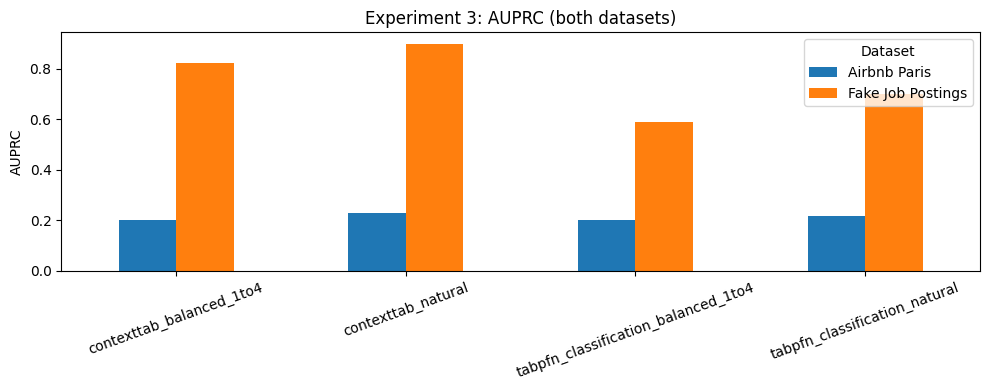

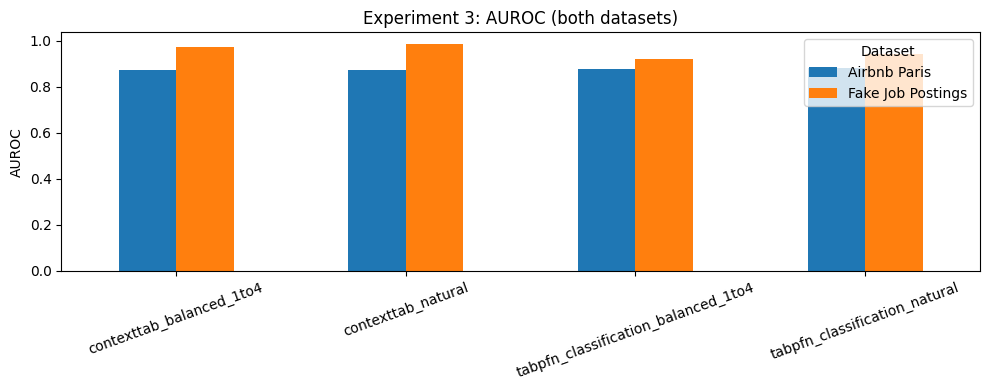

In [7]:
sub = df[df["section"] == "exp3"] if len(df) else df
if not len(sub):
    print("keine Exp-3-Runs")
else:
    for ds in datasets:
        s = sub[sub["dataset"] == ds]
        if not len(s):
            continue
        g = s.groupby("model")
        mean, std = g[["AUPRC", "AUROC", "runtime_s"]].mean(), g[["AUPRC", "AUROC"]].std()
        order = mean["AUPRC"].sort_values(ascending=False).index
        tab = pd.DataFrame({
            "AUPRC": mean["AUPRC"].map("{:.4f}".format),
            "SD (AUPRC)": std["AUPRC"].map("{:.4f}".format),
            "AUROC": mean["AUROC"].map("{:.4f}".format),
            "SD (AUROC)": std["AUROC"].map("{:.4f}".format),
            "Runtime (s)": mean["runtime_s"].map("{:.1f}".format),
        }).loc[order]
        tab.index.name = "Model"

        sty = (tab.style.format(escape=None)
               .format_index(escape="latex", axis="index").format_index(escape="latex", axis="columns")
               .map_index(lambda v: "font-weight: bold;", axis="columns")
               .hide(axis="index", names=True).hide(axis="columns", names=True))
        sty.to_latex(f"{RESULT_DIR}/exp3_{ds}.tex", hrules=True, convert_css=True, position_float="centering",
                     column_format="lrrrrr",
                     caption=f"Experiment 3 -- TFM classification on {DS_LABEL[ds]}: AUPRC, AUROC and runtime per model and context variant, averaged over three seeds.",
                     label=f"tab:exp3_{ds}")
        print(f"=== Experiment 3 – {ds} ===")
        display(tab)

    for metric, fname in [("AUPRC", "auprc"), ("AUROC", "auroc")]:
        piv = sub.pivot_table(index="model", columns="dataset", values=metric, aggfunc="mean").sort_index()
        piv.columns = [DS_LABEL[c] for c in piv.columns]
        ax = piv.plot.bar(figsize=(10, 4), rot=20)
        ax.set_title(f"Experiment 3: {metric} (both datasets)")
        ax.set_ylabel(metric)
        ax.set_xlabel("")
        ax.legend(title="Dataset")
        plt.tight_layout()
        plt.savefig(f"{DIAGRAM_DIR}/exp3_{fname}.pdf", facecolor="white", edgecolor="white")
        plt.show()
        plt.close()